In [ ]:

!rm -rf /kaggle/working/*

In [1]:
# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

!pip install -q transformers datasets accelerate seaborn

import os, re, ast, random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

# Plot folder
os.makedirs("results_figures", exist_ok=True)

# Style
sns.set(style="whitegrid")

In [47]:
# ============================================================
# 1. CONFIG
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_NAME = "roberta-base"

FINANC_SAMPLE_SIZE = None
MOBILE_SAMPLE_SIZE = None

MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 4

LR = 5e-5          # 5e-6 se thoda better
WEIGHT_DECAY = 0.001
DROPOUT = 0.40

DOMAIN_LOSS_WEIGHT = 0.3
GRAD_CLIP = 1.0
PATIENCE = 2

MAX_DUP_PER_TEXT = 50

USE_DFST = True
USE_MLM = True

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

label_names = ["Negative", "Neutral", "Positive"]

Device: cuda


In [48]:
# ============================================================
# 2. LOAD DATA
# ============================================================

finance_df = pd.read_csv("/kaggle/input/datasets/ujabalkr894/finun-title/SEntFiN-v1.1.csv")
mobile_df = pd.read_csv("/kaggle/input/datasets/ujabalkr894/ttttaaa/Mobile Reviews Sentiment.csv")

print("Finance shape:", finance_df.shape)
print("Mobile shape:", mobile_df.shape)

print("Finance columns:", finance_df.columns.tolist())
print("Mobile columns:", mobile_df.columns.tolist())

Finance shape: (10753, 4)
Mobile shape: (50000, 25)
Finance columns: ['S No.', 'Title', 'Decisions', 'Words']
Mobile columns: ['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'review_text', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'review_length', 'word_count', 'helpful_votes', 'source']


In [49]:
# ============================================================
# 3. COLUMN SET
# ============================================================


# finance dataset:
# TItle    = text
# Decisions    = label

finance_df = finance_df.rename(columns={
    "Title": "text",
    "Decisions": "label"
})

# mobile dataset:
# review_text     = text
# sentoment       = label

mobile_df = mobile_df.rename(columns={
      "review_text": "text",
       "sentiment": "label"
})

finance_df = finance_df[["text", "label"]].copy()
mobile_df = mobile_df[["text", "label"]].copy()

In [50]:
# ============================================================
# 4. CLEAN TEXT
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

finance_df["text"] = finance_df["text"].apply(clean_text)
mobile_df["text"] = mobile_df["text"].apply(clean_text)

In [51]:
# ============================================================
# 5. LABEL MAPPING
# ============================================================

def extract_finance_label(x):
    x = str(x).lower().strip()

    if "negative" in x or x in ["0", "neg"]:
        return "Negative"
    elif "neutral" in x or x in ["1", "neu"]:
        return "Neutral"
    elif "positive" in x or x in ["2", "pos"]:
        return "Positive"
    else:
        return None


def extract_mobile_label(x):
    x = str(x).lower().strip()

    
    try:
        d = ast.literal_eval(str(x))
        if isinstance(d, dict):
            x = list(d.values())[0].lower().strip()
    except:
        pass

    if "negative" in x or "bearish" in x or x in ["0", "neg"]:
        return "Negative"
    elif "neutral" in x or x in ["1", "neu"]:
        return "Neutral"
    elif "positive" in x or "bullish" in x or x in ["2", "pos"]:
        return "Positive"
    else:
        return None


finance_df["label"] = finance_df["label"].apply(extract_finance_label)
mobile_df["label"] = mobile_df["label"].apply(extract_mobile_label)

finance_df = finance_df.dropna()
#mobile_df = mobile_df.dropna()

finance_df = finance_df[finance_df["label"].isin(label2id)]
mobile_df = mobile_df[mobile_df["label"].isin(label2id)]

finance_df["label"] = finance_df["label"].map(label2id)
mobile_df["label"] = mobile_df["label"].map(label2id)

finance_df = finance_df.drop_duplicates(subset=["text"])
#mobile_df = mobile_df.drop_duplicates(subset=["text"])

print("Finance labels:")
print(finance_df["label"].value_counts())

print("\nMobile labels:")
print(mobile_df["label"].value_counts())

Finance labels:
label
1    3995
2    3347
0    3265
Name: count, dtype: int64

Mobile labels:
label
2    27540
1    12549
0     9911
Name: count, dtype: int64


In [52]:
# ============================================================
# 6. SAMPLE SIZE SET
# ============================================================

SEED = 42

FINANCE_SAMPLE_SIZE =None      # None = Full dataset
MOBILE_SAMPLE_SIZE = None       # None = Full dataset

if FINANCE_SAMPLE_SIZE is None:
    finance_df = finance_df.reset_index(drop=True)
else:
    finance_df = finance_df.sample(
        n=min(FINANCE_SAMPLE_SIZE, len(finance_df)),
        random_state=SEED
    ).reset_index(drop=True)

if MOBILE_SAMPLE_SIZE is None:
    mobile_df = mobile_df.reset_index(drop=True)
else:
    mobile_df = mobile_df.sample(
        n=min(MOBILE_SAMPLE_SIZE, len(mobile_df)),
        random_state=SEED
    ).reset_index(drop=True)

print("Finance sample:", finance_df.shape)
print("Mobile sample:", mobile_df.shape)

print("\nFinance sample labels:")
print(finance_df["label"].value_counts())

print("\nMobile sample labels:")
print(mobile_df["label"].value_counts())

Finance sample: (10607, 2)
Mobile sample: (50000, 2)

Finance sample labels:
label
1    3995
2    3347
0    3265
Name: count, dtype: int64

Mobile sample labels:
label
2    27540
1    12549
0     9911
Name: count, dtype: int64


In [53]:
# ============================================================
# OVERSAMPLING FINANCE DATASET
# ============================================================

from sklearn.utils import resample
import pandas as pd

# Separate classes
df_pos = finance_df[finance_df["label"] == 2]
df_neu = finance_df[finance_df["label"] == 1]
df_neg = finance_df[finance_df["label"] == 0]

# Find majority size
max_size = max(len(df_pos), len(df_neu), len(df_neg))

# Oversample minority classes
df_neu_up = resample(
    df_neu,
    replace=True,
    n_samples=max_size,
    random_state=42
)

df_neg_up = resample(
    df_neg,
    replace=True,
    n_samples=max_size,
    random_state=42
)

# Combine
finance_df_balanced = pd.concat([
    df_pos,
    df_neu_up,
    df_neg_up
])

# Shuffle
finance_df_balanced = finance_df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(finance_df_balanced["label"].value_counts())

label
1    3995
0    3995
2    3347
Name: count, dtype: int64


In [54]:
# ============================================================
# 7. DFST APPLY
# ============================================================

def make_dfst_text(text, domain):
    text = str(text)

    if USE_DFST:
        if domain == "source":
            return f"[GENERAL] {text} [SOURCE] {text}"
        else:
            return f"[GENERAL] {text} [TARGET] {text}"
    else:
        return text


# Finance = Source
finance_df["text"] = finance_df["text"].apply(
    lambda x: make_dfst_text(x, "source")
)

# Mobile = Target
mobile_df["text"] = mobile_df["text"].apply(
    lambda x: make_dfst_text(x, "target")
)

print(finance_df.head())
print(mobile_df.head())

                                                text  label
0  [GENERAL] spicejet to issue crore warrants to ...      1
1  [GENERAL] mmtc q net loss at rs crore [SOURCE]...      1
2  [GENERAL] mid cap funds can deliver more stay ...      2
3  [GENERAL] mid caps now turn into market darlin...      2
4  [GENERAL] market seeing patience if not convic...      1
                                                text  label
0  [GENERAL] not worth the money spent wouldn t r...      0
1  [GENERAL] absolutely love this phone the camer...      2
2  [GENERAL] loving the clean ui and fast updates...      2
3  [GENERAL] build quality feels solid and durabl...      2
4  [GENERAL] not bad for daily use but could be o...      1


In [55]:
# ============================================================
# 8. TRAIN / VALIDATION SPLIT
# ============================================================

train_df, val_df = train_test_split(
    finance_df_balanced,
    test_size=0.20,
    random_state=SEED,
    stratify=finance_df_balanced["label"]
)

#test_df = mobile_df.copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
#print("Mobile Test:", test_df.shape)

Train: (9069, 2)
Val: (2268, 2)


In [56]:
# ============================================================
# TARGET MOBILE SPLIT WITH DUPLICATE CONTROL
# Mobile = Target Domain
# ============================================================

MAX_DUP_PER_TEXT = 50

print("Before duplicate control Mobile:", mobile_df.shape)
print("Mobile label distribution:")
print(mobile_df["label"].value_counts())

# Duplicate report
dup_dist = mobile_df["text"].value_counts()

print("\n========== MOBILE DUPLICATE REPORT ==========")
print("Unique Review Text :", dup_dist.shape[0])
print("Minimum Repeat     :", dup_dist.min())
print("Average Repeat     :", round(dup_dist.mean(), 2))
print("Median Repeat      :", dup_dist.median())
print("Maximum Repeat     :", dup_dist.max())

print("\nTop 10 repeated reviews:")
print(dup_dist.head(10))

# Limit duplicates
mobile_controlled_df = (
    mobile_df
    .groupby(["text", "label"], group_keys=False)
    .head(MAX_DUP_PER_TEXT)
    .reset_index(drop=True)
)

print("\nAfter duplicate control:", mobile_controlled_df.shape)
print("Controlled label distribution:")
print(mobile_controlled_df["label"].value_counts())

# Target train/test split
target_train_df, target_test_df = train_test_split(
    mobile_controlled_df,
    test_size=0.20,
    random_state=SEED,
    stratify=mobile_controlled_df["label"]
)

target_train_df = target_train_df.reset_index(drop=True)
target_test_df = target_test_df.reset_index(drop=True)

print("\nTarget Train:", target_train_df.shape)
print("Target Test :", target_test_df.shape)

print("\nTarget Test label distribution:")
print(target_test_df["label"].value_counts())

print("\nTarget Test unique text:", target_test_df["text"].nunique())
print("Target Test duplicate text:", target_test_df.duplicated(subset=["text"]).sum())

Before duplicate control Mobile: (50000, 2)
Mobile label distribution:
label
2    27540
1    12549
0     9911
Name: count, dtype: int64

========== MOBILE DUPLICATE REPORT ==========
Unique Review Text : 110
Minimum Repeat     : 215
Average Repeat     : 454.55
Median Repeat      : 416.0
Maximum Repeat     : 724

Top 10 repeated reviews:
text
[GENERAL] battery easily lasts a day with heavy use no regrets buying this one [TARGET] battery easily lasts a day with heavy use no regrets buying this one                724
[GENERAL] design feels premium and stylish loving it so far [TARGET] design feels premium and stylish loving it so far                                                      724
[GENERAL] smooth performance even after months of use loving it so far [TARGET] smooth performance even after months of use loving it so far                                723
[GENERAL] worth every penny highly recommended loving it so far [TARGET] worth every penny highly recommended loving it so far  

In [57]:
# ============================================================
# 9. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

special_tokens = {
    "additional_special_tokens": ["[GENERAL]", "[SOURCE]", "[TARGET]"]
}

tokenizer.add_special_tokens(special_tokens)

3

In [58]:
# ============================================================
# 10. MLM ADAPTATION ON TARGET MOBILE TEXT
# Unsupervised Target Domain Adaptation
# ============================================================

from datasets import Dataset as HFDataset
from transformers import (
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

if USE_MLM:

    # केवल target_train_df use करें, target_test_df नहीं
    mlm_texts = pd.DataFrame({
        "text": target_train_df["text"].astype(str).tolist()
    })

    mlm_dataset = HFDataset.from_pandas(mlm_texts)

    def tokenize_mlm(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN
        )

    tokenized_mlm = mlm_dataset.map(
        tokenize_mlm,
        batched=True,
        remove_columns=["text"]
    )

    mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
    mlm_model.resize_token_embeddings(len(tokenizer))

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=0.15
    )

    mlm_args = TrainingArguments(
        output_dir="./roberta_mobile_mlm",
        num_train_epochs=2,
        per_device_train_batch_size=8,
        learning_rate=5e-5,
        weight_decay=0.001,
        warmup_ratio=0.10,
        logging_steps=20,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    mlm_trainer = Trainer(
        model=mlm_model,
        args=mlm_args,
        train_dataset=tokenized_mlm,
        data_collator=data_collator
    )

    mlm_trainer.train()

    mlm_model.save_pretrained("./roberta_mobile_mlm")
    tokenizer.save_pretrained("./roberta_mobile_mlm")

    BASE_MODEL = "./roberta_mobile_mlm"

else:
    BASE_MODEL = MODEL_NAME

print("BASE_MODEL:", BASE_MODEL)

Map:   0%|          | 0/4400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
20,1.748876
40,0.800158
60,0.646081
80,0.699088
100,0.479012
120,0.439000
140,0.585198
160,0.240240
180,0.381481
200,0.241261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BASE_MODEL: ./roberta_mobile_mlm


In [ ]:
# ============================================================
# 11. DATASET CLASS + DATALOADERS
# ============================================================

from torch.utils.data import Dataset, DataLoader
import torch

class ABSADomainDataset(Dataset):
    def __init__(self, dataframe, tokenizer, domain_label):
        self.texts = dataframe["text"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.domain_label = domain_label

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "domain": torch.tensor(self.domain_label, dtype=torch.long)
        }


# Source = Finance
source_train_dataset = ABSADomainDataset(train_df, tokenizer, domain_label=0)
source_val_dataset   = ABSADomainDataset(val_df, tokenizer, domain_label=0)

# Target = Mobile
target_train_dataset = ABSADomainDataset(target_train_df, tokenizer, domain_label=1)
target_test_dataset  = ABSADomainDataset(target_test_df, tokenizer, domain_label=1)


source_train_loader = DataLoader(
    source_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

source_val_loader = DataLoader(
    source_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

target_train_loader = DataLoader(
    target_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

target_test_loader = DataLoader(
    target_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Source Train:", len(source_train_dataset))
print("Source Val  :", len(source_val_dataset))
print("Target Train:", len(target_train_dataset))
print("Target Test :", len(target_test_dataset))

In [63]:
source_train_dataset = ABSADomainDataset(
    train_df,
    tokenizer,
    domain_label=0
)

source_val_dataset = ABSADomainDataset(
    val_df,
    tokenizer,
    domain_label=0
)

target_train_dataset = ABSADomainDataset(
    target_train_df,
    tokenizer,
    domain_label=1
)

target_test_dataset = ABSADomainDataset(
    target_test_df,
    tokenizer,
    domain_label=1
)

source_train_loader = DataLoader(
    source_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

source_val_loader = DataLoader(
    source_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

target_train_loader = DataLoader(
    target_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

target_test_loader = DataLoader(
    target_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [64]:
# ============================================================
# 12. GRL + RoBERTa DANN MODEL
# ============================================================

class GradientReverseFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReverseLayer(nn.Module):
    def forward(self, x, lambd):
        return GradientReverseFunction.apply(x, lambd)


class RobertaDANN(nn.Module):
    def __init__(self, model_name, num_labels=3):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.resize_token_embeddings(len(tokenizer))

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.40)

        self.sentiment_classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, num_labels)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, 2)
        )

        self.grl = GradientReverseLayer()

    def forward(self, input_ids, attention_mask, grl_lambda=1.0):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        sentiment_logits = self.sentiment_classifier(cls_output)

        reversed_features = self.grl(cls_output, grl_lambda)
        domain_logits = self.domain_classifier(reversed_features)

        return sentiment_logits, domain_logits


model = RobertaDANN(BASE_MODEL).to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./roberta_mobile_mlm
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [65]:
# ============================================================
# 13. PENALTY FOCAL LOSS
# ============================================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)

class_weights = torch.tensor( class_weights, 
                             dtype=torch.float).to(device)
print("Class weights:", class_weights)


class PenalizedFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=1.5, min_prob=0.10, collapse_weight=0.10):
        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.min_prob = min_prob
        self.collapse_weight = collapse_weight

    def forward(self, logits, labels):
        ce_unweighted = F.cross_entropy(
            logits,
            labels,
            weight=self.class_weights,
            reduction="none"
        )

        pt = torch.exp(-ce_unweighted)
        focal = ((1 - pt) ** self.gamma) * ce_unweighted
        if self.class_weights is not None:
            weights = self.class_weights[labels]
            focal = focal * weights
            
        focal = focal.mean()

        probs = torch.softmax(logits, dim=1)
        avg_probs = probs.mean(dim=0)

        collapse_penalty = torch.relu(self.min_prob - avg_probs).sum()

        loss = focal + self.collapse_weight * collapse_penalty

        return loss


sentiment_criterion =nn.CrossEntropyLoss(weight=class_weights)
    #gamma=2.0,
    #min_prob=0.15,
    #collapse_weight=0.20
domain_criterion = nn.CrossEntropyLoss()

Class weights: tensor([0.9459, 0.9459, 1.1292], device='cuda:0')


In [67]:
# ============================================================
# 14. OPTIMIZER
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.001
)

total_steps = EPOCHS * len(source_train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * total_steps),
    num_training_steps=total_steps
)

In [68]:
# ============================================================
# 15. EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader):
    model.eval()

    all_true = []
    all_pred = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                grl_lambda=1.0
            )

            preds = torch.argmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(all_true, all_pred)

    return acc, np.array(all_true), np.array(all_pred)

In [69]:
# ============================================================
# 16. PENALIZED SCORE
# ============================================================

MIN_CLASS_RECALL = 0.30
MAX_SAFE_ACC = 0.95
MAX_TRAIN_VAL_GAP = 0.12

CLASS_RECALL_PENALTY_WEIGHT = 1.50
OVERCONFIDENCE_PENALTY_WEIGHT = 0.20
OVERFIT_GAP_PENALTY_WEIGHT = 0.40


def compute_penalized_score(y_true, y_pred, train_acc=None, val_acc=None):
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        zero_division=0
    )

    macro_f1 = np.mean(f1)

    recall_penalty = 0.0

    for r in recall:
        if r < MIN_CLASS_RECALL:
            recall_penalty += MIN_CLASS_RECALL - r

    recall_penalty *= CLASS_RECALL_PENALTY_WEIGHT

    overconfidence_penalty = 0.0

    if train_acc is not None and train_acc > MAX_SAFE_ACC:
        overconfidence_penalty += train_acc - MAX_SAFE_ACC

    if val_acc is not None and val_acc > MAX_SAFE_ACC:
        overconfidence_penalty += val_acc - MAX_SAFE_ACC

    overconfidence_penalty *= OVERCONFIDENCE_PENALTY_WEIGHT

    gap_penalty = 0.0

    if train_acc is not None and val_acc is not None:
        gap = train_acc - val_acc

        if gap > MAX_TRAIN_VAL_GAP:
            gap_penalty = gap - MAX_TRAIN_VAL_GAP

    gap_penalty *= OVERFIT_GAP_PENALTY_WEIGHT

    base_score = 0.50 * acc + 0.50 * macro_f1

    penalized_score = (
        base_score
        - recall_penalty
        - overconfidence_penalty
        - gap_penalty
    )

    details = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "recall_negative": recall[0],
        "recall_neutral": recall[1],
        "recall_positive": recall[2],
        "recall_penalty": recall_penalty,
        "overconfidence_penalty": overconfidence_penalty,
        "gap_penalty": gap_penalty,
        "penalized_score": penalized_score
    }

    return penalized_score, details

In [70]:
# ============================================================
# 17. TRAINING: RoBERTa + DFST + MLM + DANN + PENALTY
# ============================================================

best_penalized_score = -999
best_epoch = -1

total_steps = EPOCHS * len(source_train_loader)
global_step = 0

for epoch in range(EPOCHS):

    DOMAIN_LOSS_WEIGHT = 0.03

    model.train()

    train_true = []
    train_pred = []

    total_loss = 0
    total_sent_loss = 0
    total_domain_loss = 0

    target_iter = iter(target_train_loader)

    progress_bar = tqdm(
        source_train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for source_batch in progress_bar:

        try:
            target_batch = next(target_iter)
        except StopIteration:
            target_iter = iter(target_train_loader)
            target_batch = next(target_iter)

        source_input_ids = source_batch["input_ids"].to(device)
        source_attention_mask = source_batch["attention_mask"].to(device)
        source_labels = source_batch["label"].to(device)

        target_input_ids = target_batch["input_ids"].to(device)
        target_attention_mask = target_batch["attention_mask"].to(device)

        source_domain_labels = torch.zeros(
            source_input_ids.size(0),
            dtype=torch.long,
            device=device
        )

        target_domain_labels = torch.ones(
            target_input_ids.size(0),
            dtype=torch.long,
            device=device
        )

        optimizer.zero_grad()

        p = float(global_step) / max(1, total_steps)
        grl_lambda = min(
            0.10,
            2.0 / (1.0 + np.exp(-5 * p)) - 1.0
        )

        source_sent_logits, source_domain_logits = model(
            input_ids=source_input_ids,
            attention_mask=source_attention_mask,
            grl_lambda=grl_lambda
        )

        _, target_domain_logits = model(
            input_ids=target_input_ids,
            attention_mask=target_attention_mask,
            grl_lambda=grl_lambda
        )

        sent_loss = sentiment_criterion(
            source_sent_logits,
            source_labels
        )

        source_domain_loss = domain_criterion(
            source_domain_logits,
            source_domain_labels
        )

        target_domain_loss = domain_criterion(
            target_domain_logits,
            target_domain_labels
        )

        domain_loss = source_domain_loss + target_domain_loss

        loss = sent_loss + DOMAIN_LOSS_WEIGHT * domain_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        global_step += 1

        total_loss += loss.item()
        total_sent_loss += sent_loss.item()
        total_domain_loss += domain_loss.item()

        preds = torch.argmax(source_sent_logits, dim=1)

        train_true.extend(source_labels.detach().cpu().numpy())
        train_pred.extend(preds.detach().cpu().numpy())

        progress_bar.set_postfix({
            "loss": round(loss.item(), 4),
            "sent": round(sent_loss.item(), 4),
            "domain": round(domain_loss.item(), 4),
            "grl": round(grl_lambda, 4),
            "dw": round(DOMAIN_LOSS_WEIGHT, 4)
        })

    train_acc = accuracy_score(train_true, train_pred)

    finance_val_acc, finance_y_true, finance_y_pred = evaluate(
        model,
        source_val_loader
    )

    mobile_acc, mobile_y_true, mobile_y_pred = evaluate(
        model,
        target_test_loader
    )

    penalized_score, details = compute_penalized_score(
        y_true=mobile_y_true,
        y_pred=mobile_y_pred,
        train_acc=train_acc,
        val_acc=finance_val_acc
    )

    print("\n" + "="*80)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*80)

    print(f"Domain Loss Weight      : {DOMAIN_LOSS_WEIGHT:.4f}")
    print(f"Train Accuracy          : {train_acc:.4f}")
    print(f"Finance Val Accuracy    : {finance_val_acc:.4f}")
    print(f"Mobile Cross Accuracy   : {mobile_acc:.4f}")
    print(f"Mobile Macro F1         : {details['macro_f1']:.4f}")

    print("\nMobile Class Recall:")
    print(f"Negative Recall         : {details['recall_negative']:.4f}")
    print(f"Neutral Recall          : {details['recall_neutral']:.4f}")
    print(f"Positive Recall         : {details['recall_positive']:.4f}")

    print("\nPenalty:")
    print(f"Recall Penalty          : {details['recall_penalty']:.4f}")
    print(f"Overconfidence Penalty  : {details['overconfidence_penalty']:.4f}")
    print(f"Train-Val Gap Penalty   : {details['gap_penalty']:.4f}")
    print(f"Final Penalized Score   : {penalized_score:.4f}")

    print("\nMobile Classification Report:")
    print(classification_report(
        mobile_y_true,
        mobile_y_pred,
        target_names=label_names,
        zero_division=0
    ))

    print("Mobile Confusion Matrix:")
    print(confusion_matrix(mobile_y_true, mobile_y_pred))

    print("\nPrediction Distribution:")
    print(Counter(mobile_y_pred))

    if penalized_score > best_penalized_score:
        best_penalized_score = penalized_score
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_roberta_dfst_mlm_dann_penalty.pt"
        )

        print("\n✅ Best model saved by penalized score!")

print("\nTraining finished.")
print("Best Epoch:", best_epoch)
print("Best Penalized Score:", best_penalized_score)

Epoch 1/4:   0%|          | 0/1134 [00:00<?, ?it/s]


Epoch 1/4
Domain Loss Weight      : 0.0300
Train Accuracy          : 0.7138
Finance Val Accuracy    : 0.8241
Mobile Cross Accuracy   : 0.8100
Mobile Macro F1         : 0.8044

Mobile Class Recall:
Negative Recall         : 0.9075
Neutral Recall          : 0.7867
Positive Recall         : 0.7300

Penalty:
Recall Penalty          : 0.0000
Overconfidence Penalty  : 0.0000
Train-Val Gap Penalty   : 0.0000
Final Penalized Score   : 0.8072

Mobile Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.91      0.92       400
     Neutral       0.64      0.79      0.71       300
    Positive       0.84      0.73      0.78       400

    accuracy                           0.81      1100
   macro avg       0.81      0.81      0.80      1100
weighted avg       0.82      0.81      0.81      1100

Mobile Confusion Matrix:
[[363  22  15]
 [ 22 236  42]
 [  0 108 292]]

Prediction Distribution:
Counter({np.int64(0): 385, np.int64(1): 366, np.int6

Epoch 2/4:   0%|          | 0/1134 [00:00<?, ?it/s]


Epoch 2/4
Domain Loss Weight      : 0.0300
Train Accuracy          : 0.8511
Finance Val Accuracy    : 0.8660
Mobile Cross Accuracy   : 0.8982
Mobile Macro F1         : 0.8878

Mobile Class Recall:
Negative Recall         : 0.9675
Neutral Recall          : 0.7033
Positive Recall         : 0.9750

Penalty:
Recall Penalty          : 0.0000
Overconfidence Penalty  : 0.0000
Train-Val Gap Penalty   : 0.0000
Final Penalized Score   : 0.8930

Mobile Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96       400
     Neutral       0.95      0.70      0.81       300
    Positive       0.83      0.97      0.90       400

    accuracy                           0.90      1100
   macro avg       0.91      0.88      0.89      1100
weighted avg       0.91      0.90      0.89      1100

Mobile Confusion Matrix:
[[387   0  13]
 [ 22 211  67]
 [  0  10 390]]

Prediction Distribution:
Counter({np.int64(2): 470, np.int64(0): 409, np.int6

Epoch 3/4:   0%|          | 0/1134 [00:00<?, ?it/s]


Epoch 3/4
Domain Loss Weight      : 0.0300
Train Accuracy          : 0.9139
Finance Val Accuracy    : 0.8836
Mobile Cross Accuracy   : 0.9591
Mobile Macro F1         : 0.9579

Mobile Class Recall:
Negative Recall         : 0.9675
Neutral Recall          : 0.9267
Positive Recall         : 0.9750

Penalty:
Recall Penalty          : 0.0000
Overconfidence Penalty  : 0.0000
Train-Val Gap Penalty   : 0.0000
Final Penalized Score   : 0.9585

Mobile Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96       400
     Neutral       0.97      0.93      0.95       300
    Positive       0.97      0.97      0.97       400

    accuracy                           0.96      1100
   macro avg       0.96      0.96      0.96      1100
weighted avg       0.96      0.96      0.96      1100

Mobile Confusion Matrix:
[[387   0  13]
 [ 22 278   0]
 [  0  10 390]]

Prediction Distribution:
Counter({np.int64(0): 409, np.int64(2): 403, np.int6

Epoch 4/4:   0%|          | 0/1134 [00:00<?, ?it/s]


Epoch 4/4
Domain Loss Weight      : 0.0300
Train Accuracy          : 0.9485
Finance Val Accuracy    : 0.8818
Mobile Cross Accuracy   : 0.9600
Mobile Macro F1         : 0.9591

Mobile Class Recall:
Negative Recall         : 0.9675
Neutral Recall          : 0.9633
Positive Recall         : 0.9500

Penalty:
Recall Penalty          : 0.0000
Overconfidence Penalty  : 0.0000
Train-Val Gap Penalty   : 0.0000
Final Penalized Score   : 0.9596

Mobile Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97       400
     Neutral       0.94      0.96      0.95       300
    Positive       0.97      0.95      0.96       400

    accuracy                           0.96      1100
   macro avg       0.96      0.96      0.96      1100
weighted avg       0.96      0.96      0.96      1100

Mobile Confusion Matrix:
[[387   0  13]
 [ 11 289   0]
 [  0  20 380]]

Prediction Distribution:
Counter({np.int64(0): 398, np.int64(2): 393, np.int6


BEST Mobile Cross-Domain Final Result
Best Epoch              : 4
Mobile Accuracy         : 0.9600
Mobile Macro F1         : 0.9591
Penalized Score         : 0.9576

Class-wise Recall:
Negative Recall         : 0.9675
Neutral Recall          : 0.9633
Positive Recall         : 0.9500

Mobile Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97       400
     Neutral       0.94      0.96      0.95       300
    Positive       0.97      0.95      0.96       400

    accuracy                           0.96      1100
   macro avg       0.96      0.96      0.96      1100
weighted avg       0.96      0.96      0.96      1100

Mobile Confusion Matrix:
[[387   0  13]
 [ 11 289   0]
 [  0  20 380]]

Prediction Distribution:
Counter({np.int64(0): 398, np.int64(2): 393, np.int64(1): 309})


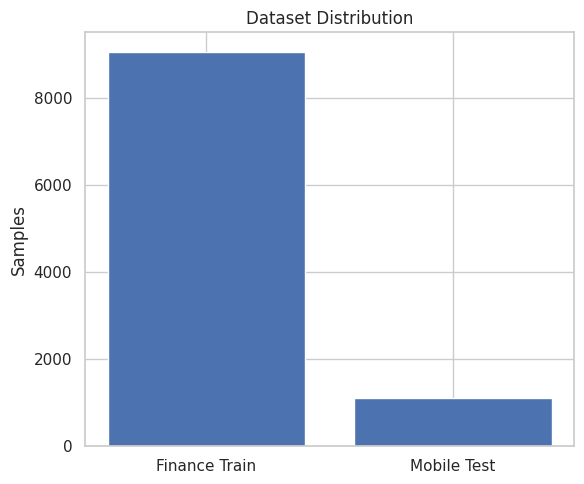

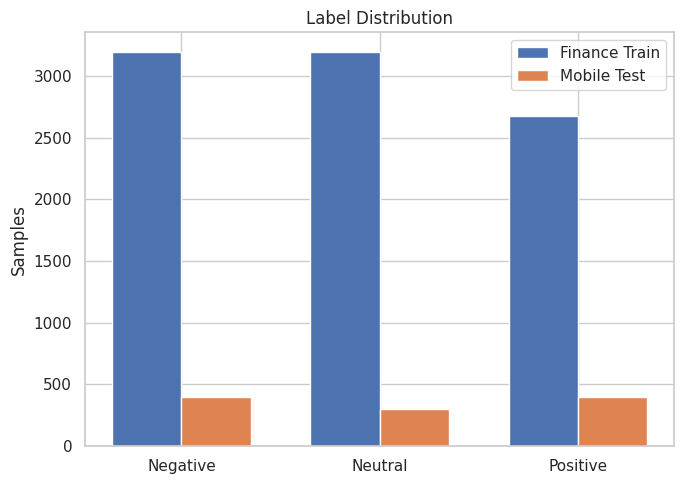

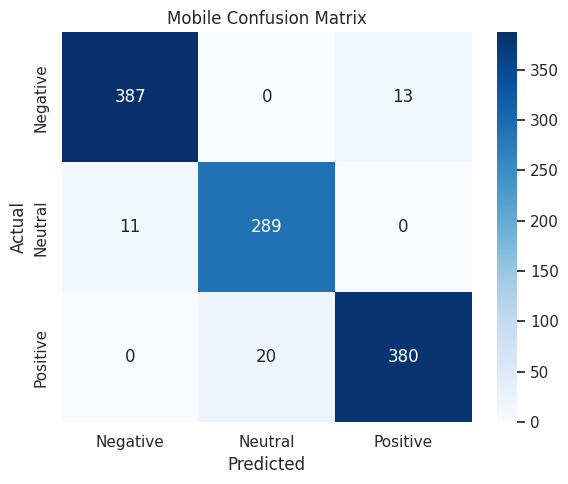

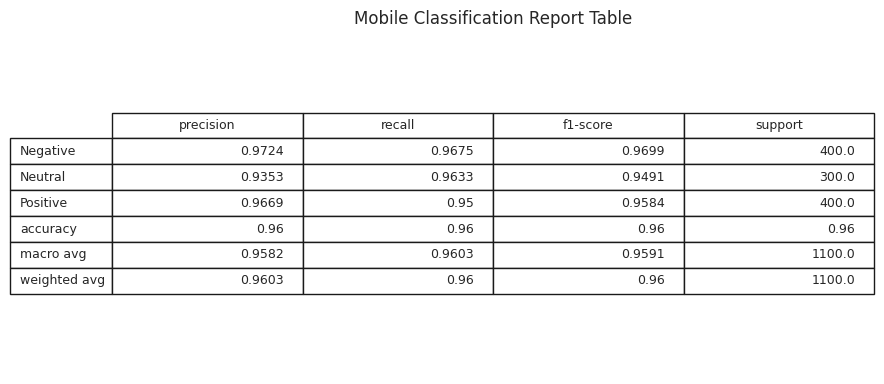

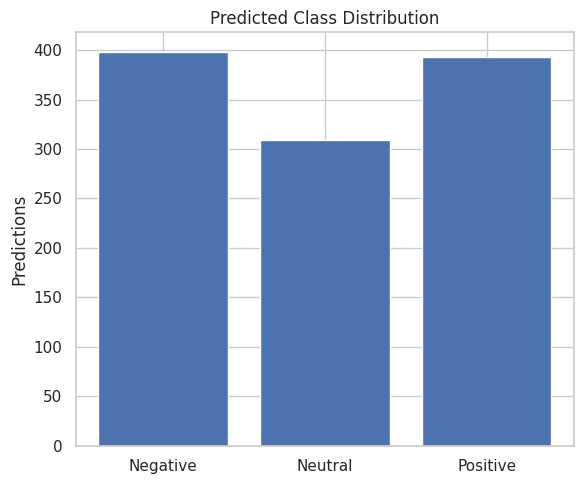

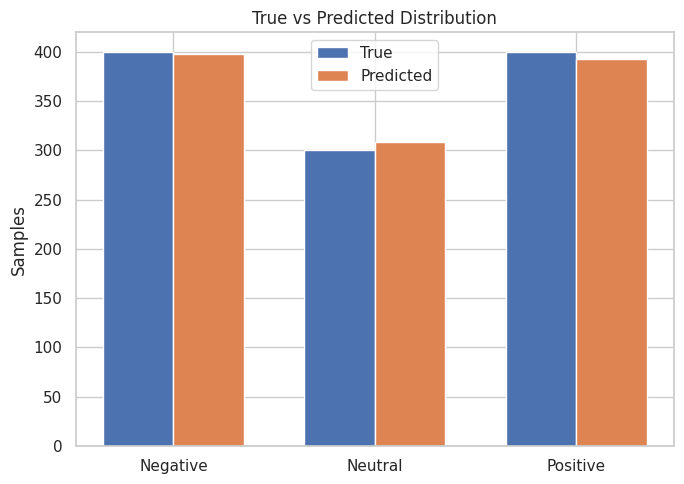


All final result plots saved in results_figures folder.


In [71]:
# ============================================================
# 18. FINAL BEST MOBILE RESULT + SAVE ALL PLOTS
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

os.makedirs("results_figures", exist_ok=True)

LABEL_NAMES = label_names
LABEL_IDS = [0, 1, 2]

# Load best model
model.load_state_dict(
    torch.load(
        "best_roberta_dfst_mlm_dann_penalty.pt",
        map_location=device
    )
)

model.to(device)

# Final evaluation
final_acc, y_true, y_pred = evaluate(
    model,
    target_test_loader
)

final_score, final_details = compute_penalized_score(
    y_true=y_true,
    y_pred=y_pred,
    train_acc=None,
    val_acc=final_acc
)

print("\n" + "="*80)
print("BEST Mobile Cross-Domain Final Result")
print("="*80)

print(f"Best Epoch              : {best_epoch}")
print(f"Mobile Accuracy         : {final_acc:.4f}")
print(f"Mobile Macro F1         : {final_details['macro_f1']:.4f}")
print(f"Penalized Score         : {final_score:.4f}")

print("\nClass-wise Recall:")
print(f"Negative Recall         : {final_details['recall_negative']:.4f}")
print(f"Neutral Recall          : {final_details['recall_neutral']:.4f}")
print(f"Positive Recall         : {final_details['recall_positive']:.4f}")

print("\nMobile Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=LABEL_NAMES,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=LABEL_IDS)

print("Mobile Confusion Matrix:")
print(cm)

print("\nPrediction Distribution:")
print(Counter(y_pred))

# ============================================================
# SAVE RESULT SUMMARY CSV
# ============================================================

summary_df = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Mobile Accuracy",
        "Mobile Macro F1",
        "Penalized Score",
        "Negative Recall",
        "Neutral Recall",
        "Positive Recall"
    ],
    "Value": [
        best_epoch,
        final_acc,
        final_details["macro_f1"],
        final_score,
        final_details["recall_negative"],
        final_details["recall_neutral"],
        final_details["recall_positive"]
    ]
})

summary_df.to_csv(
    "results_figures/mobile_final_result_summary.csv",
    index=False
)

# ============================================================
# 1. DATASET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 5))
plt.bar(
    ["Finance Train", "Mobile Test"],
    [len(train_df), len(target_test_df)]
)
plt.ylabel("Samples")
plt.title("Dataset Distribution")
plt.tight_layout()
plt.savefig("results_figures/01_dataset_distribution.png", dpi=300)
plt.show()

# ============================================================
# 2. LABEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

train_counts = train_df["label"].value_counts().sort_index()
test_counts = target_test_df["label"].value_counts().sort_index()

x = np.arange(len(LABEL_NAMES))
width = 0.35

plt.bar(x - width/2, train_counts.values, width, label="Finance Train")
plt.bar(x + width/2, test_counts.values, width, label="Mobile Test")

plt.xticks(x, LABEL_NAMES)
plt.ylabel("Samples")
plt.title("Label Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("results_figures/02_label_distribution.png", dpi=300)
plt.show()

# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Mobile Confusion Matrix")
plt.tight_layout()
plt.savefig("results_figures/03_confusion_matrix.png", dpi=300)
plt.show()

# ============================================================
# 4. CLASSIFICATION REPORT TABLE
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("results_figures/04_classification_report.csv")

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

table = ax.table(
    cellText=np.round(report_df.values, 4),
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

plt.title("Mobile Classification Report Table")
plt.tight_layout()
plt.savefig(
    "results_figures/04_classification_report_table.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 5. PREDICTED CLASS DISTRIBUTION
# ============================================================

pred_count = pd.Series(y_pred).value_counts().reindex(LABEL_IDS, fill_value=0)

plt.figure(figsize=(6, 5))
plt.bar(LABEL_NAMES, pred_count.values)
plt.ylabel("Predictions")
plt.title("Predicted Class Distribution")
plt.tight_layout()
plt.savefig("results_figures/05_prediction_distribution.png", dpi=300)
plt.show()

# ============================================================
# 6. TRUE VS PREDICTED DISTRIBUTION
# ============================================================

true_count = pd.Series(y_true).value_counts().reindex(LABEL_IDS, fill_value=0)

x = np.arange(len(LABEL_NAMES))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, true_count.values, width, label="True")
plt.bar(x + width/2, pred_count.values, width, label="Predicted")

plt.xticks(x, LABEL_NAMES)
plt.ylabel("Samples")
plt.title("True vs Predicted Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("results_figures/06_true_vs_predicted.png", dpi=300)
plt.show()

print("\nAll final result plots saved in results_figures folder.")
# ============================================================
# EXTRA PLOTS: TRAIN / VAL / CROSS-DOMAIN ACCURACY + LOSS
# Add this at the END of Cell 18
# ============================================================

def safe_plot(values, title, ylabel, filename):
    if values is None or len(values) == 0:
        print(f"Skipped: {title} data not found")
        return
    
    plt.figure(figsize=(7, 5))
    plt.plot(range(1, len(values) + 1), values, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"results_figures/{filename}", dpi=300)
    plt.show()


